In [1]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def get_weighted_stats(group_df, val_col="latency", weight_col="count", label="") -> dict:
    """
    Calculates weighted boxplot statistics (min, q1, median, q3, max)
    Assumes group_df is already sorted by val_col if not done previously.

    @returns Dictionary of percentiles
    """
    d = group_df.sort_values(val_col)
    data = d[val_col]
    weights = d[weight_col]

    cumsum = weights.cumsum()
    cutoff = cumsum / cumsum.iloc[-1]

    # function to find value at specific percentile
    def get_quantile(q):
        # searchsorted finds the index where the cumulative weight passes the quantile
        idx = np.searchsorted(cutoff, q)
        return data.iloc[idx]

    ret = {
        "med": get_quantile(0.5),
        "q1": get_quantile(0.25),
        "q3": get_quantile(0.75),
        "whislo": data.min(),  # 0th percentile
        "whishi": get_quantile(0.99)   # 100th percentile
        # "whishi": data.max()   # 100th percentile
    }

    if label != "":
        ret["label"] = label

    return ret


In [10]:
services = ["redis", "valkey", "keydb", "acdis"]
cluster_sizes = [1,3,4,5]
cluster_percentiles = { size: {} for size in cluster_sizes}

# Create output directories
for i in cluster_sizes:
    d = f"images/{i}-nodes/"
    if not os.path.isdir(d):
        os.makedirs(d)

In [11]:
all_folders = {
    1: ["single-node/redis", "single-node/valkey", "single-node/keydb", "single-node/acdis"],
    3: ["three-nodes/redis", "three-nodes/valkey", "three-nodes/keydb", "three-nodes/acdis"],
    4: ["four-nodes/redis", "four-nodes/valkey", "four-nodes/keydb", "four-nodes/acdis"],
    5: ["five-nodes/redis", "five-nodes/valkey", "five-nodes/keydb", "five-nodes/acdis"]
}

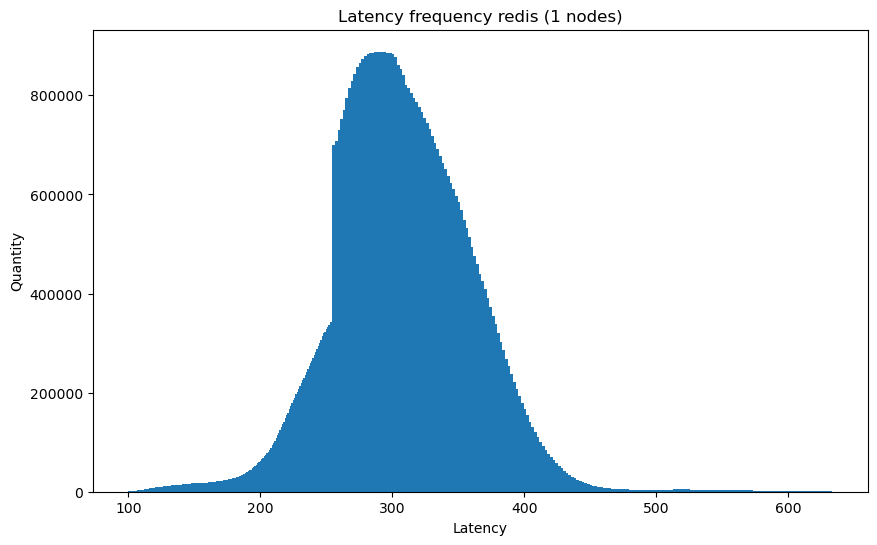

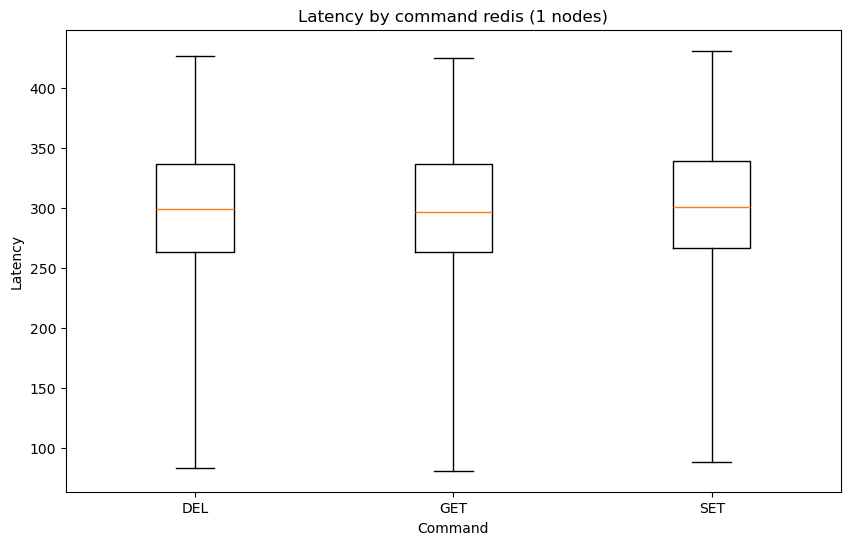

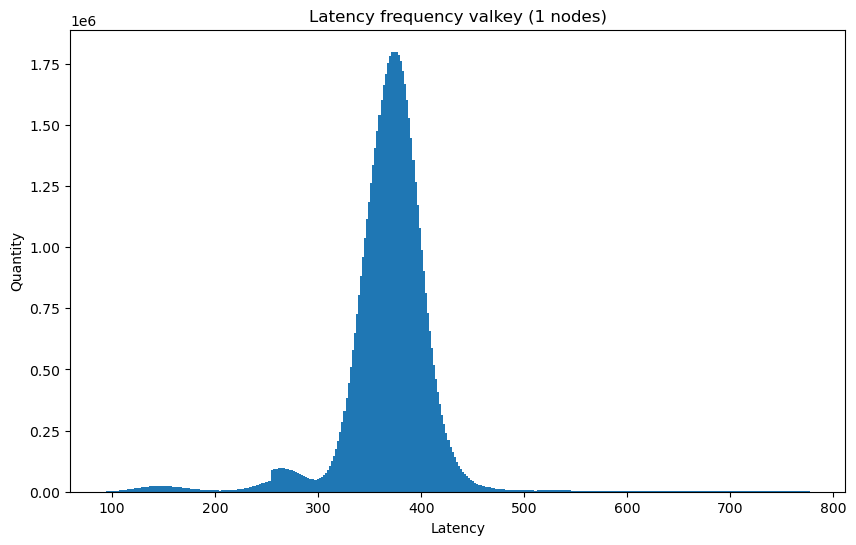

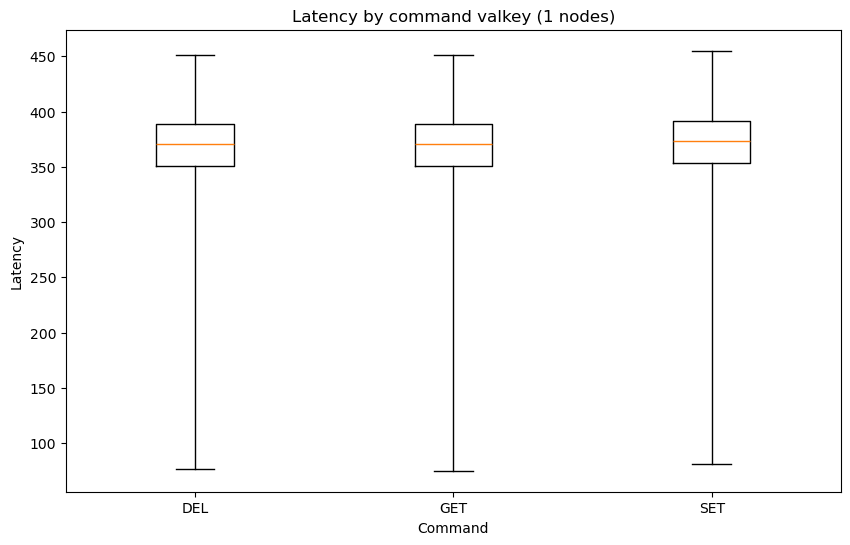

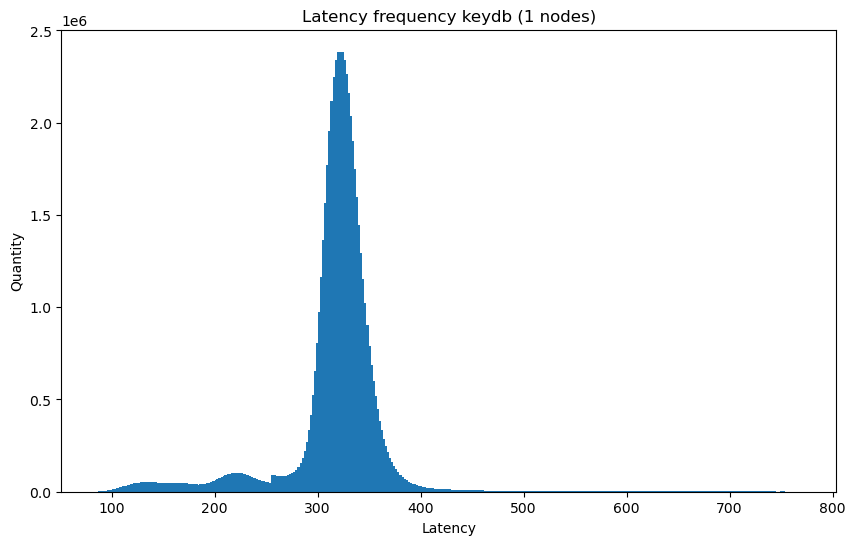

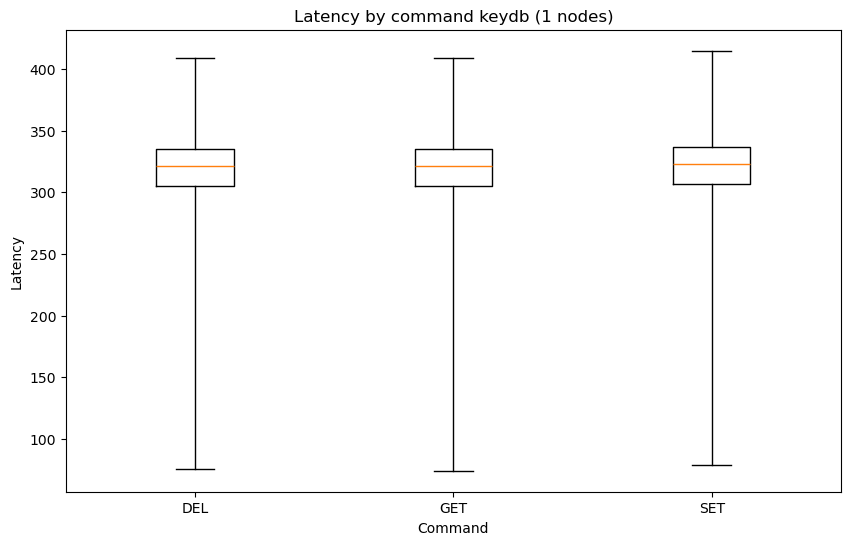

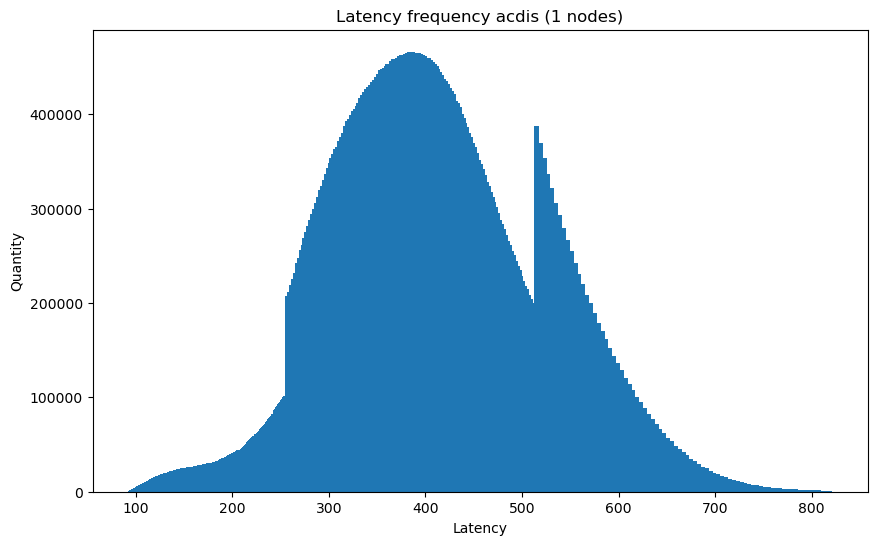

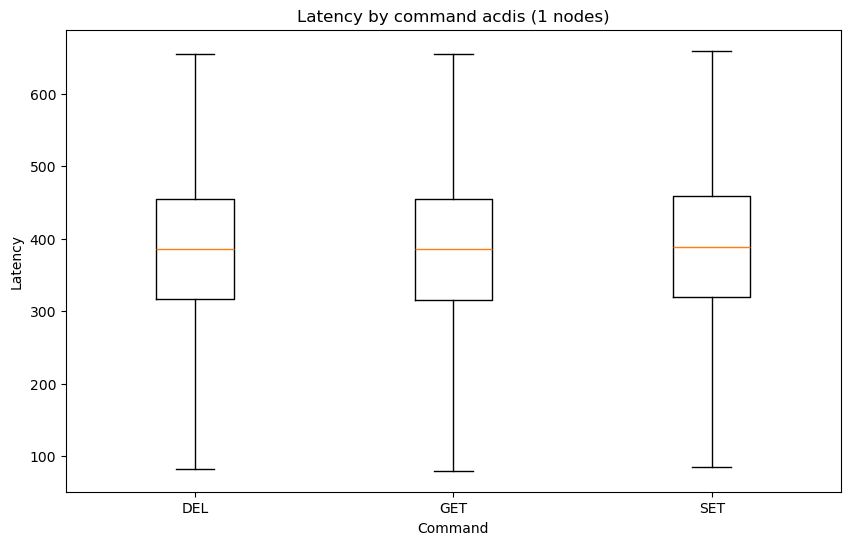

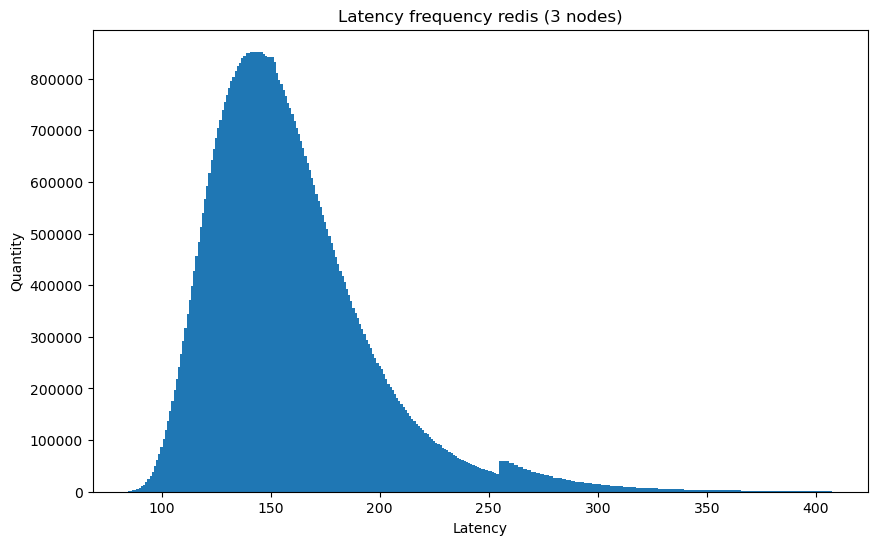

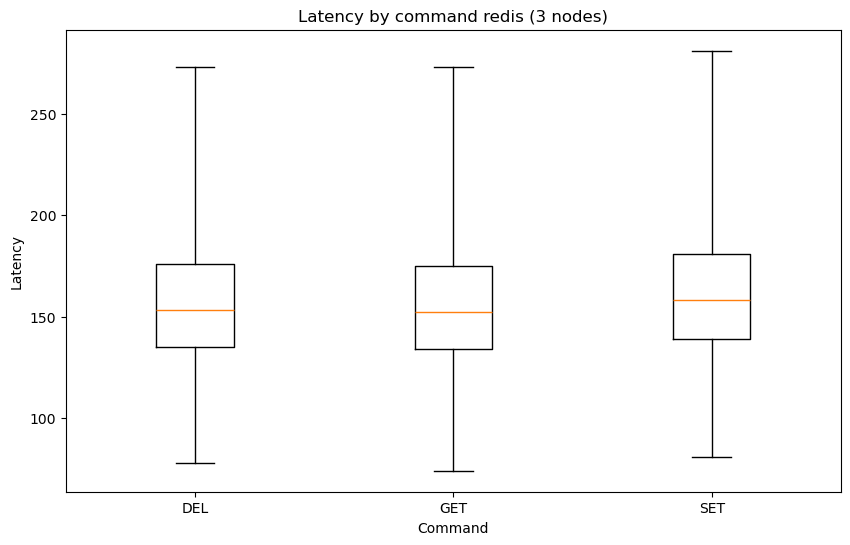

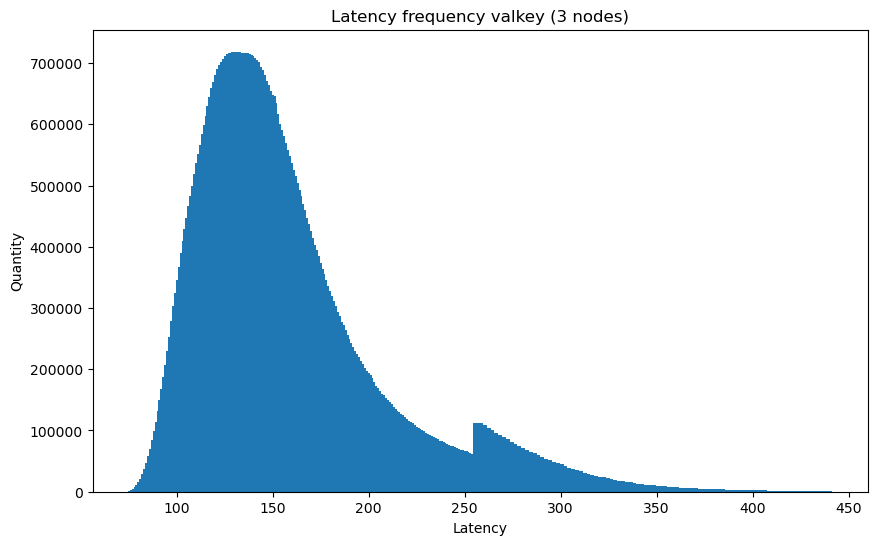

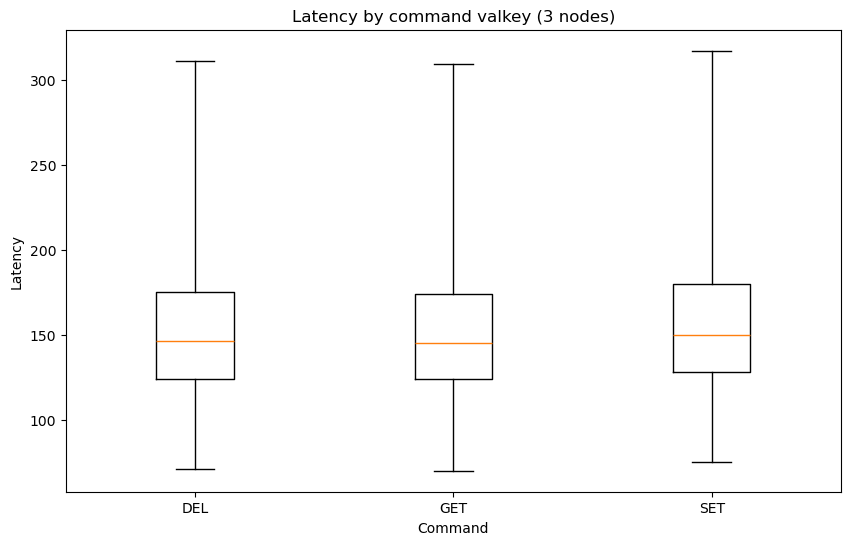

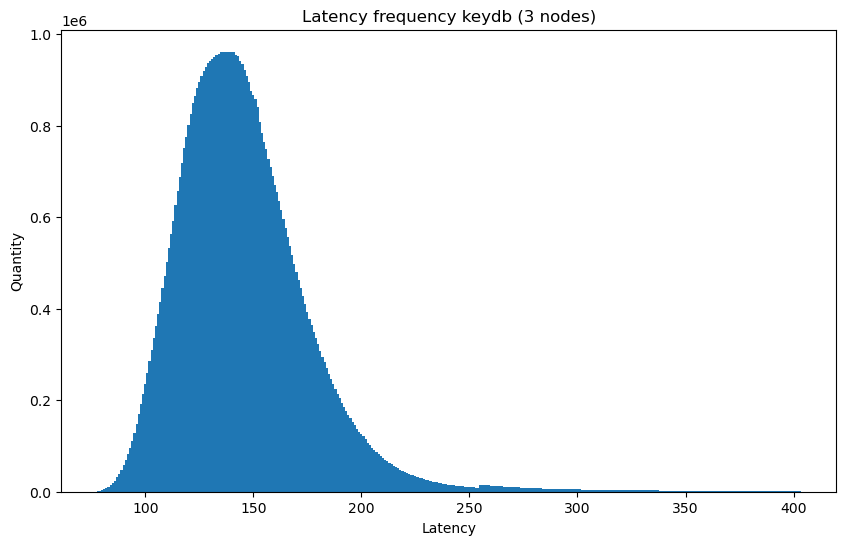

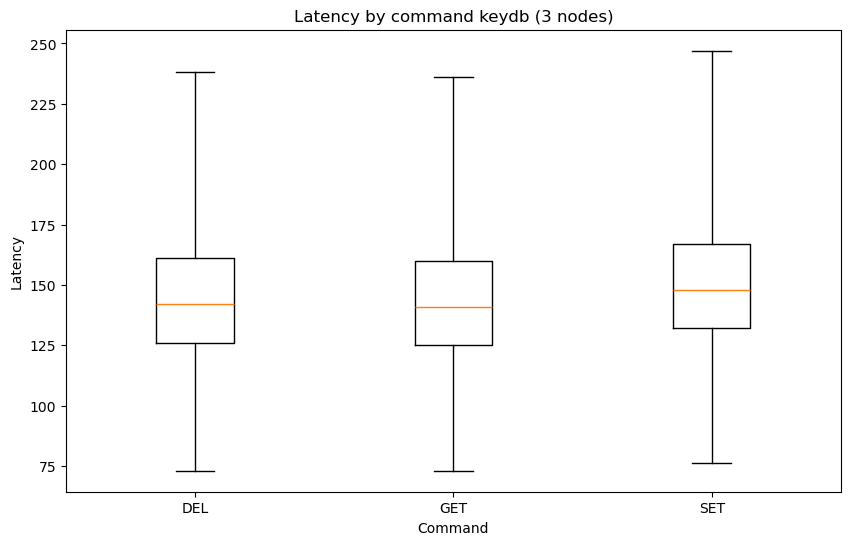

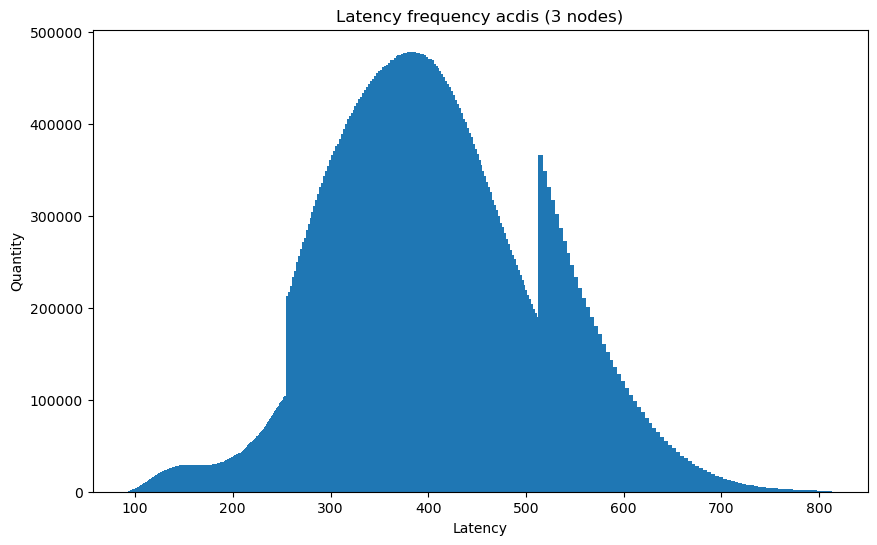

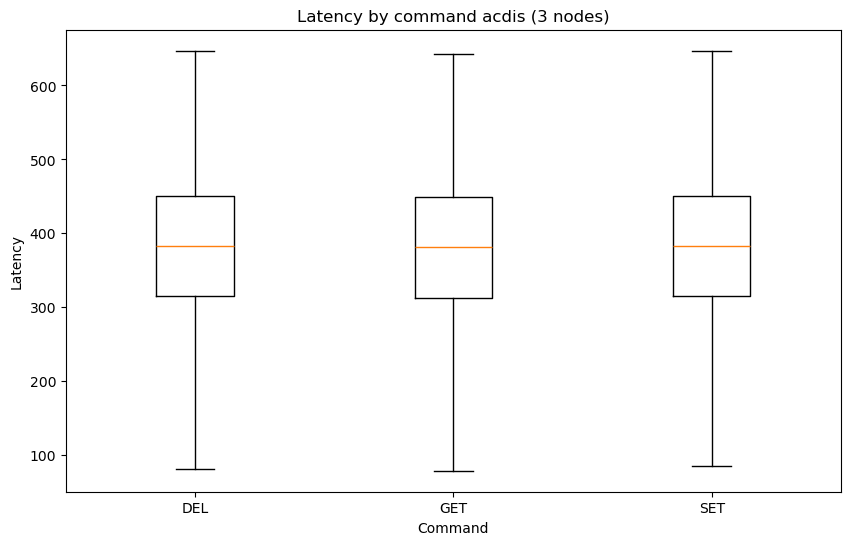

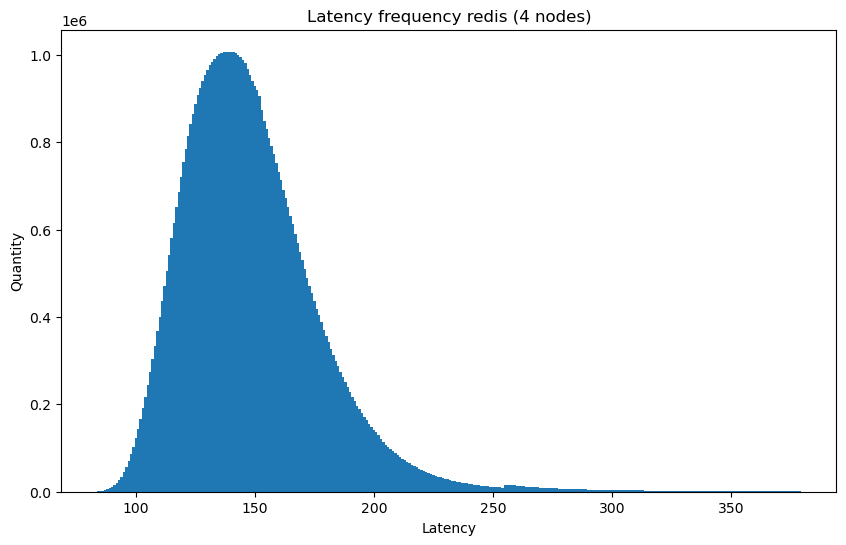

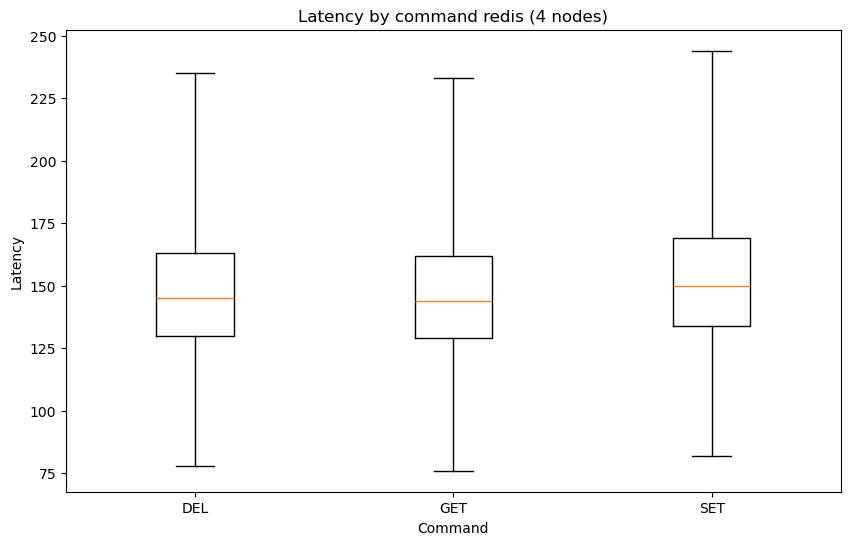

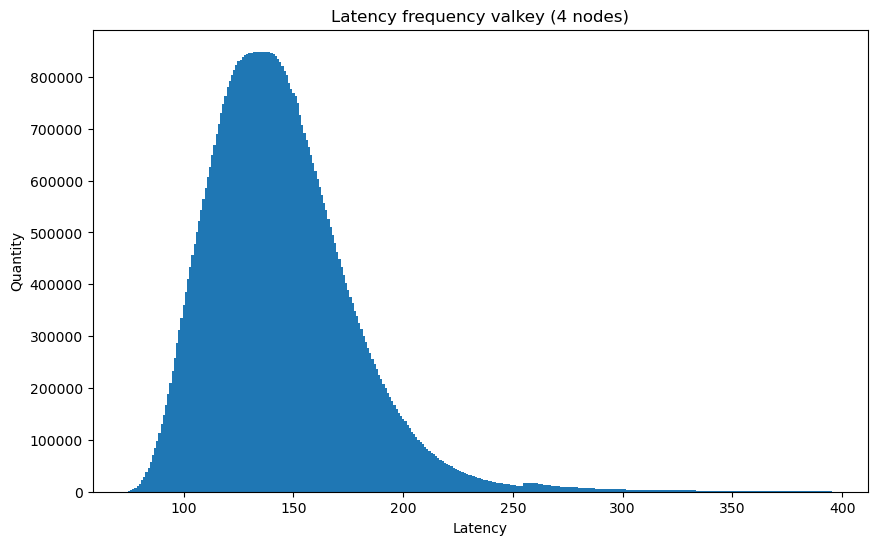

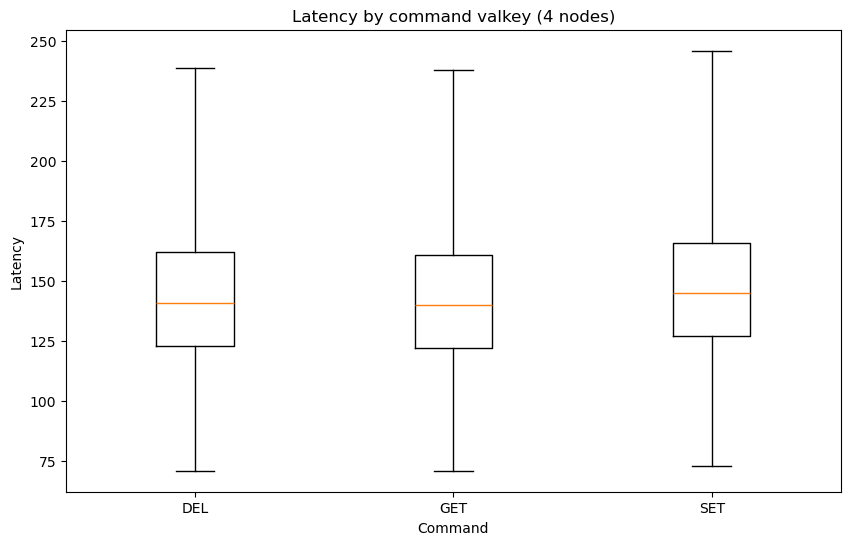

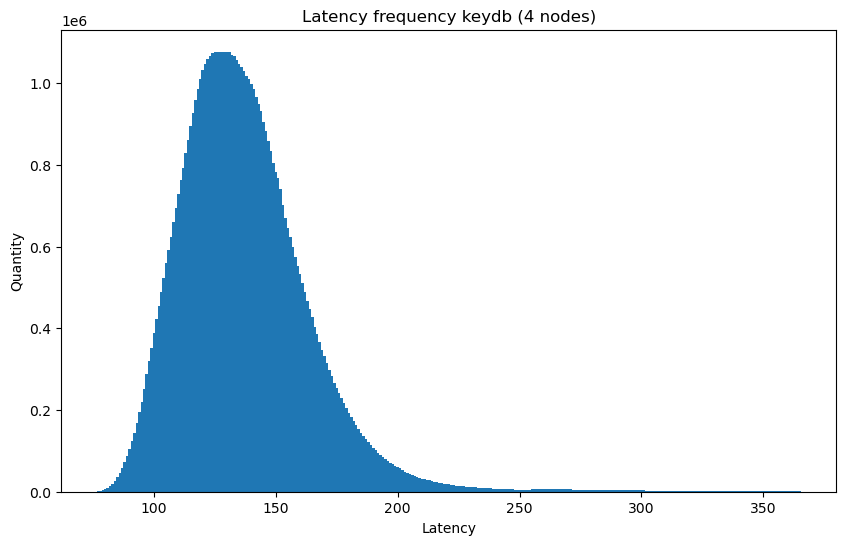

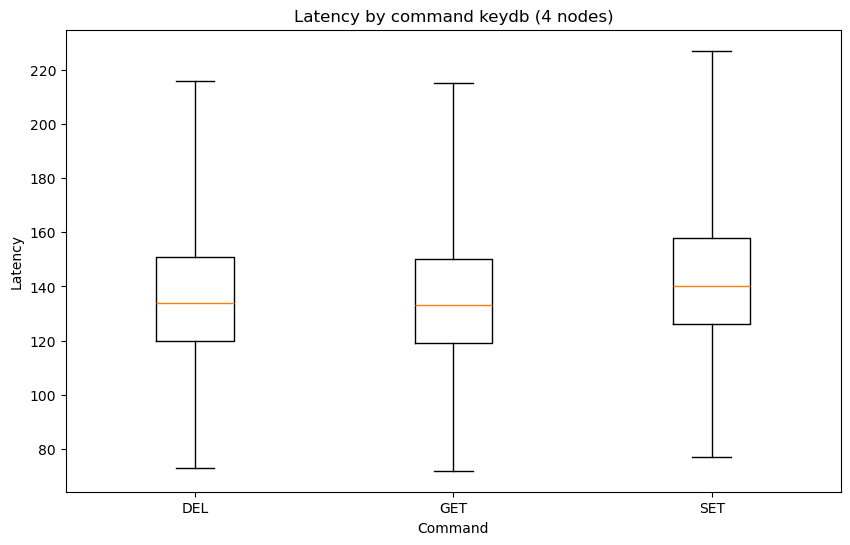

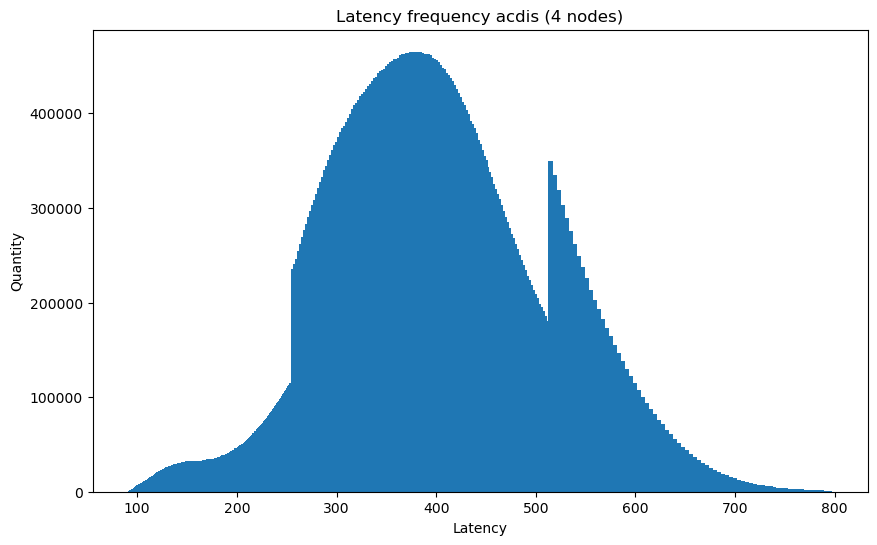

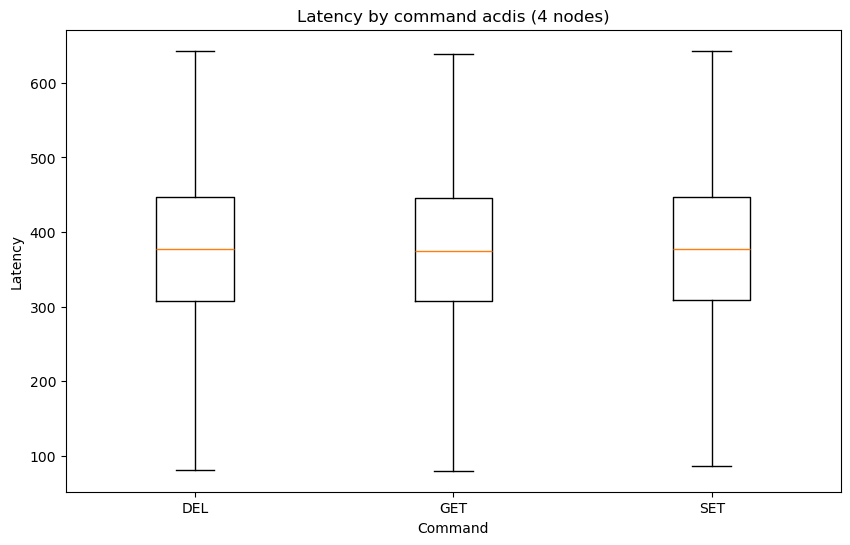

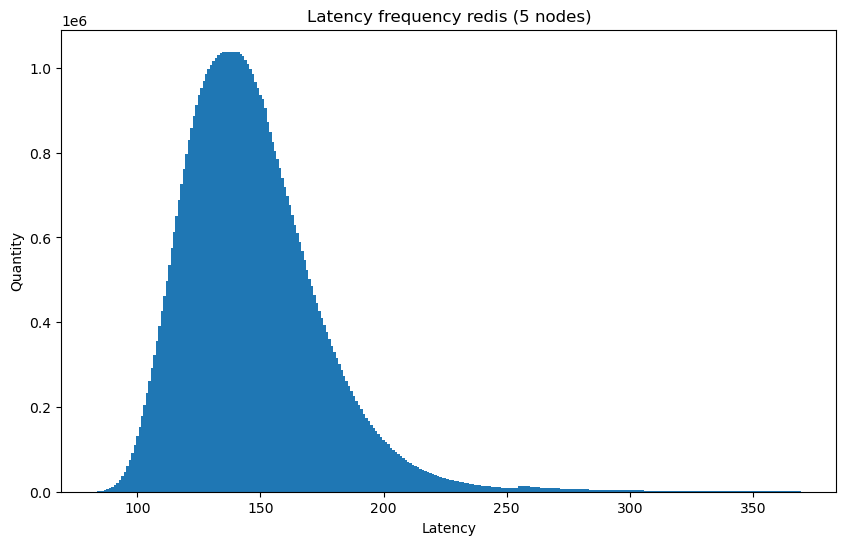

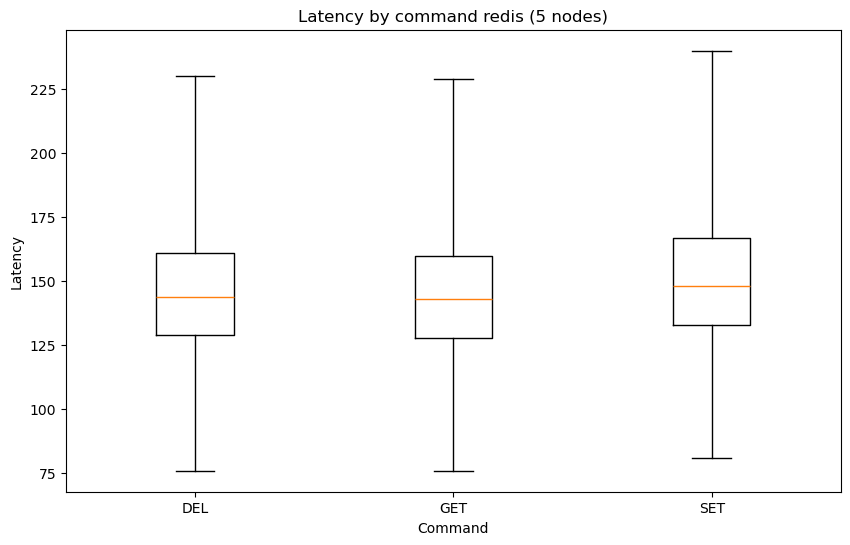

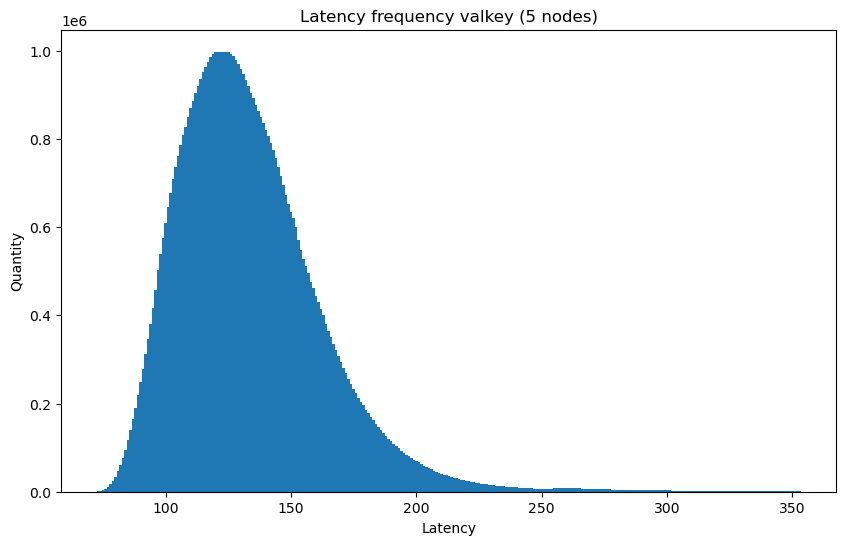

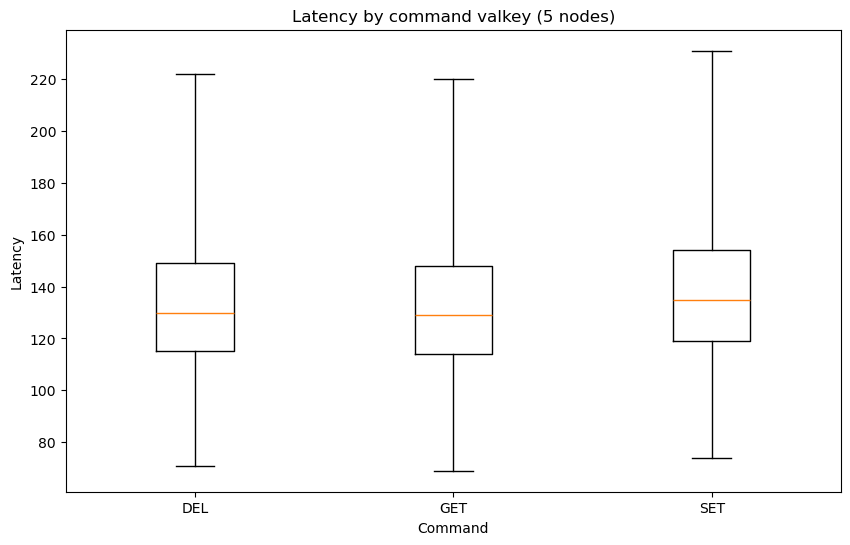

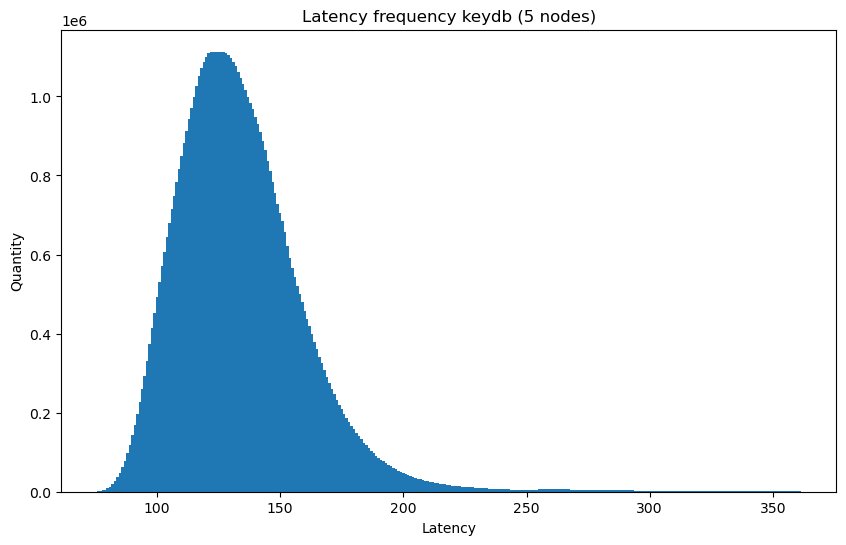

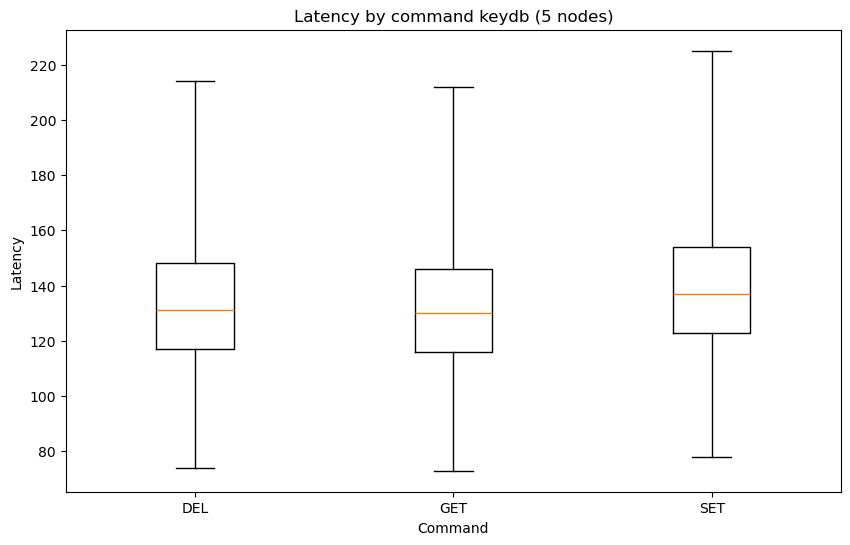

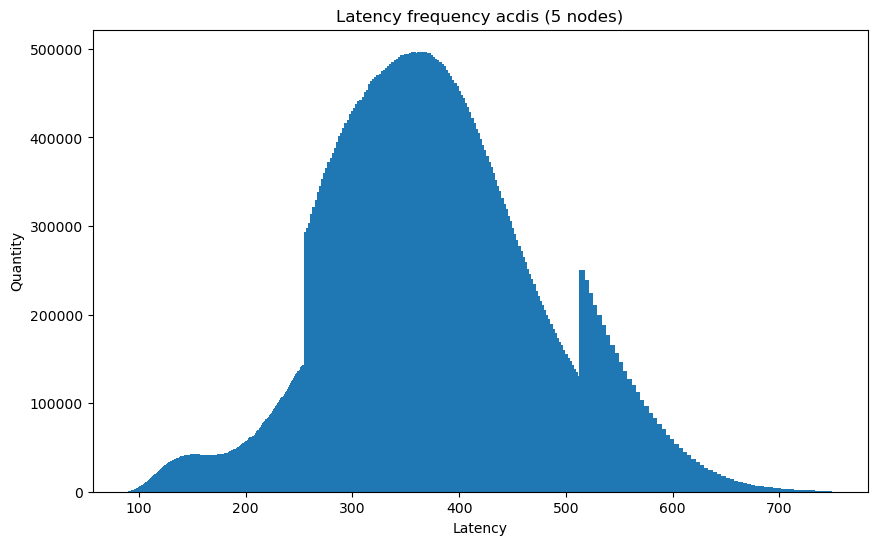

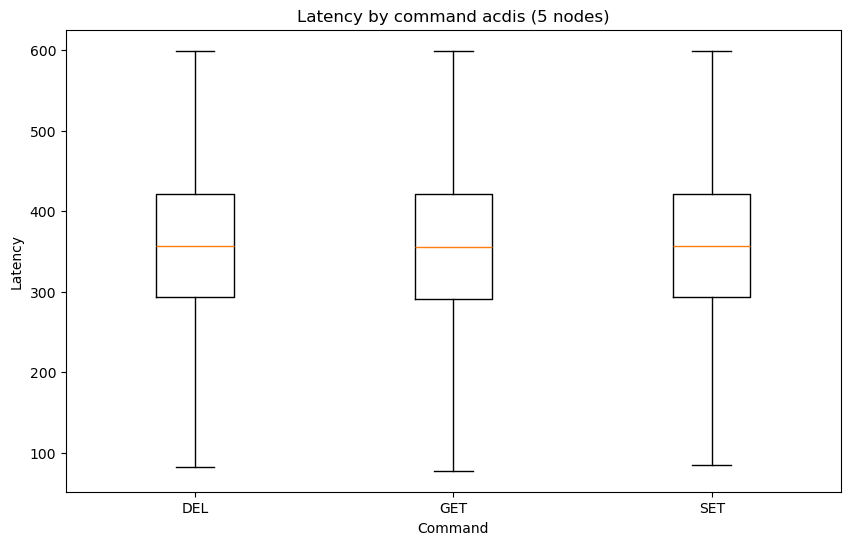

In [12]:
for cluster_size, folders in all_folders.items():
    # Dictionary of percentiles by service
    service_percentiles = {}
    for folder in folders:
        service = folder.rstrip("/").split("/")[-1]
        service.rstrip(".csv")
        files = glob.glob(f"{folder}/*.csv")
    
        # List of dataframes for this service
        service_list = []
    
        for file in files:
            df = pd.read_csv(file, comment="#")
            df["service"] = service
            df["node"] = os.path.basename(file).rstrip(".csv")
    
            service_list.append(df)
    
        service_df = pd.concat(service_list, ignore_index=True)

        # Show barcharts for each latency frequency
        fig, ax = plt.subplots(figsize=(10, 6))

        grouped_by_latency = service_df.groupby(["latency"])["count"].sum().reset_index()
        grouped_by_latency = grouped_by_latency[grouped_by_latency["count"] > 1000]
        
        plt.bar(grouped_by_latency["latency"], grouped_by_latency["count"], width=5)
        
        ax.set_title(f"Latency frequency {service} ({cluster_size} nodes)")
        ax.set_xlabel("Latency")
        ax.set_ylabel("Quantity")
        plt.savefig(f"images/{cluster_size}-nodes/{service}_latency_frequency.png")
        plt.show()
        plt.close()
    
        ### Analysis per project
        stats_list = []
        
        # Group by command to calculate stats for each box
        # If you have multiple services/nodes, you might group by ["cmd", "service"] etc.
        commands = service_df.groupby("cmd")
        for name, cmd in commands:
                # Calculate stats without exploding
                cmd_percentiles = get_weighted_stats(cmd, val_col="latency", weight_col="count", label=name)
                stats_list.append(cmd_percentiles)
    
        service_percentiles[service] = get_weighted_stats(service_df, val_col="latency", weight_col="count", label=service)
    
        # Plotting using bxp (Boxplot from pre-calculated stats)
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # bxp takes a list of dictionaries
        ax.bxp(stats_list, showfliers=False) 
        
        ax.set_title(f"Latency by command {service} ({cluster_size} nodes)")
        ax.set_xlabel("Command")
        ax.set_ylabel("Latency")
        plt.savefig(f"images/{cluster_size}-nodes/{service}_latency_by_command.png")
        plt.show()
        plt.close()

    cluster_percentiles[cluster_size] = service_percentiles


{'redis': {'med': np.int64(143), 'q1': np.int64(128), 'q3': np.int64(161), 'whislo': np.int64(76), 'whishi': np.int64(230), 'label': 'redis'}, 'valkey': {'med': np.int64(130), 'q1': np.int64(114), 'q3': np.int64(148), 'whislo': np.int64(69), 'whishi': np.int64(221), 'label': 'valkey'}, 'keydb': {'med': np.int64(131), 'q1': np.int64(117), 'q3': np.int64(147), 'whislo': np.int64(73), 'whishi': np.int64(214), 'label': 'keydb'}, 'acdis': {'med': np.int64(357), 'q1': np.int64(291), 'q3': np.int64(421), 'whislo': np.int64(78), 'whishi': np.int64(599), 'label': 'acdis'}}


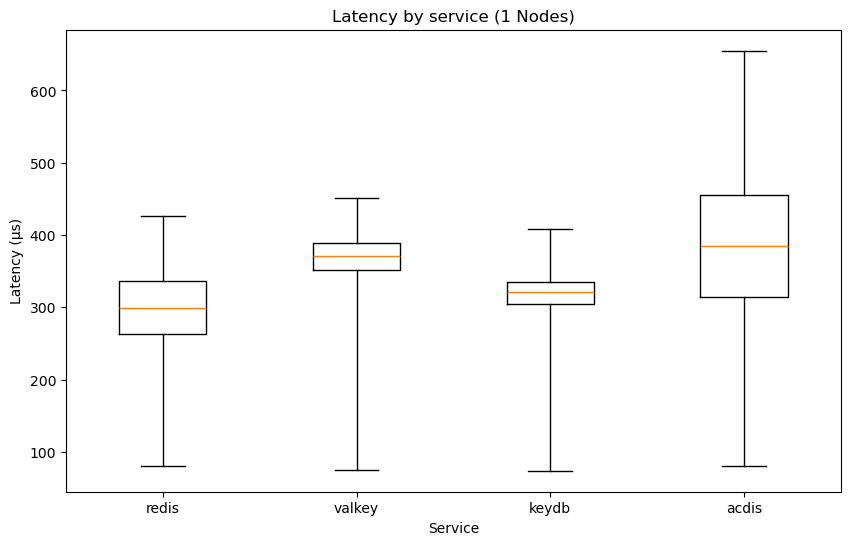

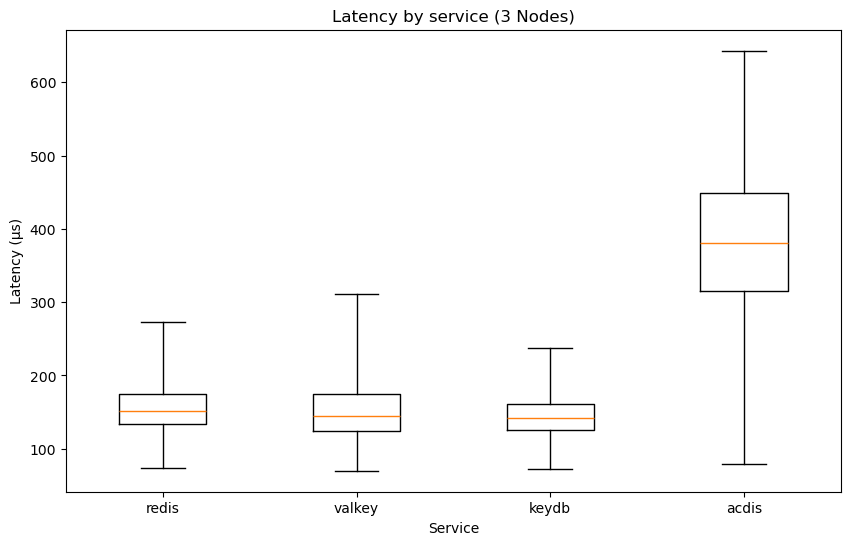

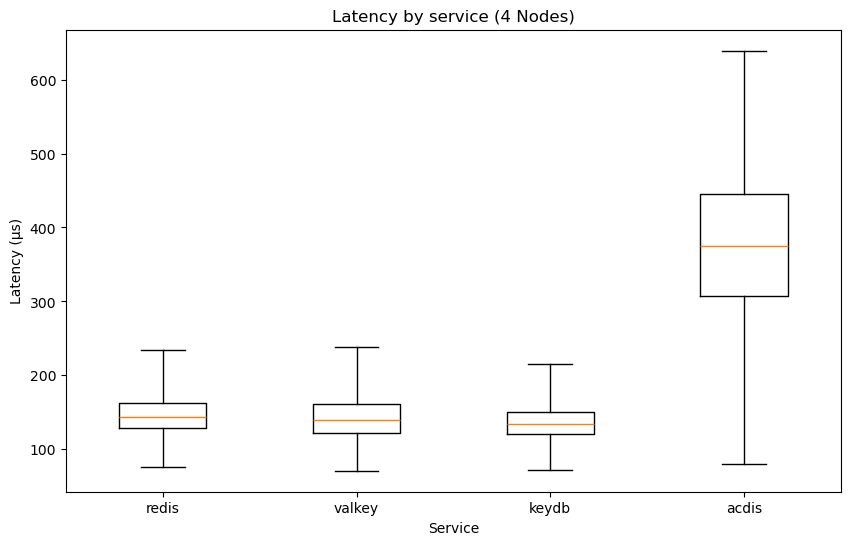

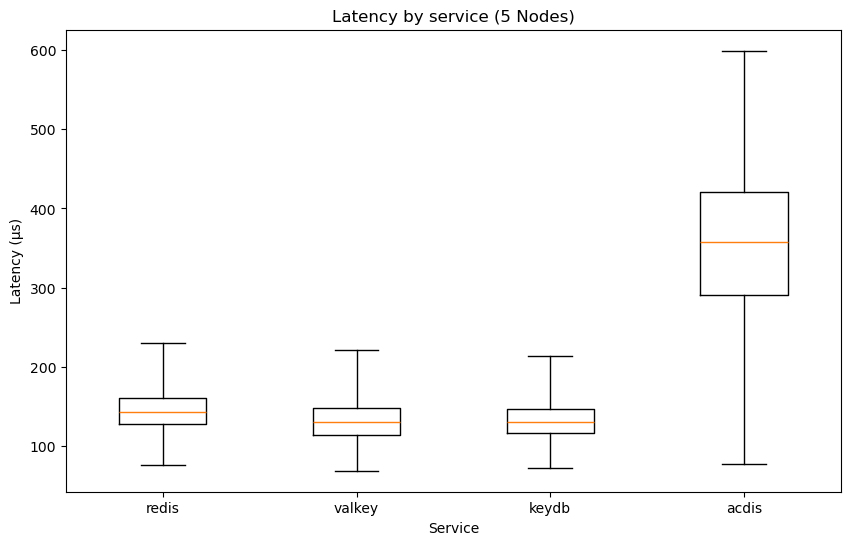

In [6]:
print(service_percentiles)

for size, percentiles in cluster_percentiles.items():
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by service ({size} Nodes)")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.show()
    plt.close()

In [7]:
# Graph latency for each service with different cluster sizes
same_service_different_size = { service: {} for service in services}
for size, service_dict in cluster_percentiles.items():
    for service, percentiles in service_dict.items():
        percentiles["label"] = size
        same_service_different_size[service][size] = percentiles
        
print(same_service_different_size)

{'redis': {1: {'med': np.int64(299), 'q1': np.int64(263), 'q3': np.int64(337), 'whislo': np.int64(81), 'whishi': np.int64(427), 'label': 1}, 3: {'med': np.int64(152), 'q1': np.int64(134), 'q3': np.int64(175), 'whislo': np.int64(74), 'whishi': np.int64(273), 'label': 3}, 4: {'med': np.int64(144), 'q1': np.int64(129), 'q3': np.int64(163), 'whislo': np.int64(76), 'whishi': np.int64(234), 'label': 4}, 5: {'med': np.int64(143), 'q1': np.int64(128), 'q3': np.int64(161), 'whislo': np.int64(76), 'whishi': np.int64(230), 'label': 5}}, 'valkey': {1: {'med': np.int64(371), 'q1': np.int64(351), 'q3': np.int64(389), 'whislo': np.int64(75), 'whishi': np.int64(451), 'label': 1}, 3: {'med': np.int64(145), 'q1': np.int64(124), 'q3': np.int64(174), 'whislo': np.int64(70), 'whishi': np.int64(311), 'label': 3}, 4: {'med': np.int64(140), 'q1': np.int64(122), 'q3': np.int64(161), 'whislo': np.int64(71), 'whishi': np.int64(238), 'label': 4}, 5: {'med': np.int64(130), 'q1': np.int64(114), 'q3': np.int64(148),

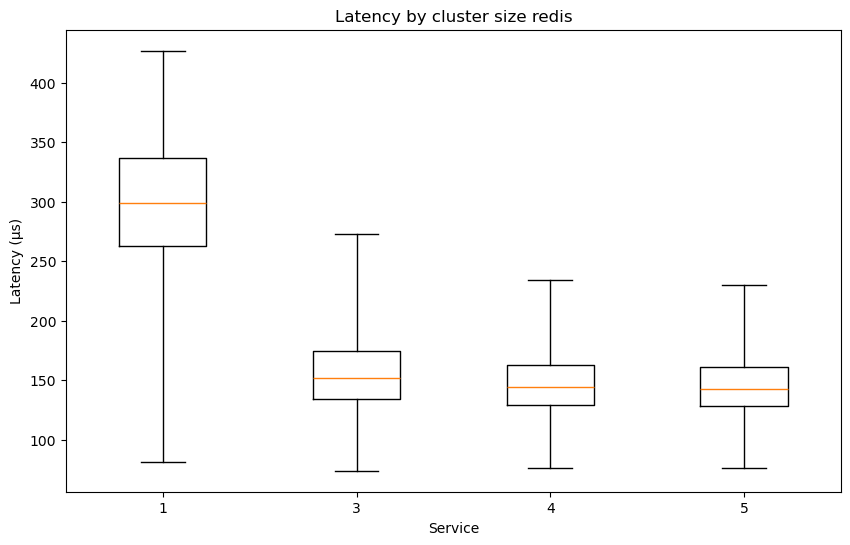

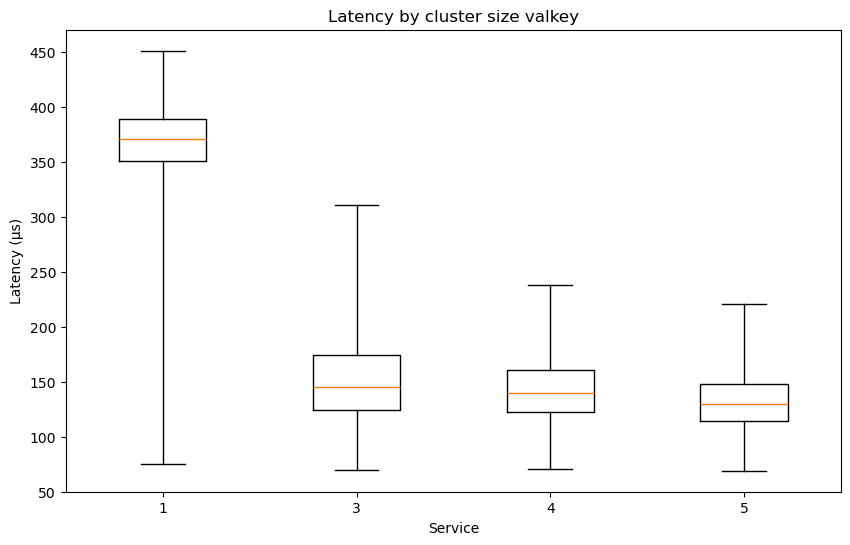

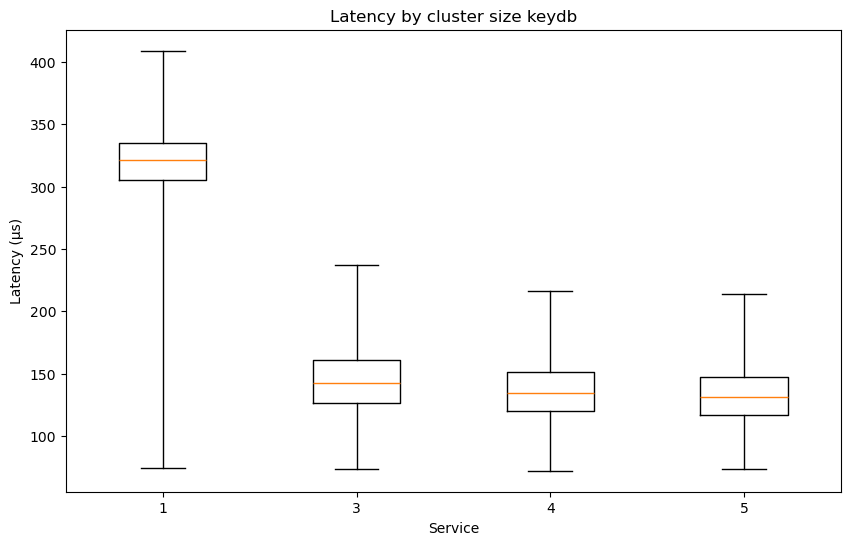

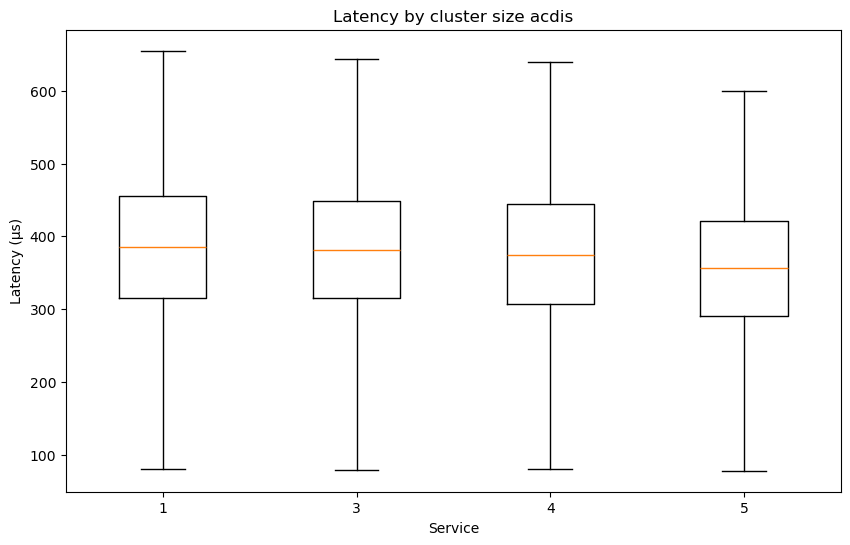

In [14]:
for service, percentiles in same_service_different_size.items():
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by cluster size {service}")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.savefig(f"images/{service}_latency_by_cluster_size.png")
    plt.show()
    plt.close()

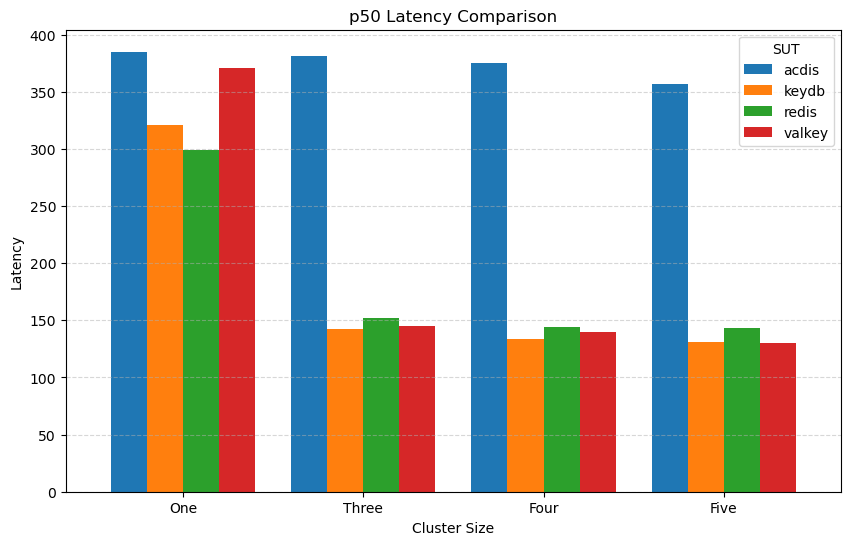

In [19]:
raw_data = same_service_different_size
records = []
for db, cats in raw_data.items():
    for cat, stats in cats.items():
        records.append({
            'Database': db, 
            'Category': cat, 
            'p50': stats['med'] # Extracting the median/p50
        })

# 2. Create DataFrame
df = pd.DataFrame(records)

# 3. Pivot: Index becomes X-axis, Columns become the bars
# This transforms the data into a shape pandas likes for grouped bars
df_pivot = df.pivot(index='Category', columns='Database', values='p50')

# Optional: Rename index to words if you prefer 'One' over '1'
df_pivot.index = df_pivot.index.map({1: 'One', 3: 'Three', 4: 'Four', 5: 'Five'})

# 4. Plot
ax = df_pivot.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('p50 Latency Comparison')
plt.ylabel('Latency')
plt.xlabel('Cluster Size')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='SUT')
plt.savefig("images/barchart_latency.png")
plt.show()